# S&P 500 Companies — Exploratory Data Analysis

## Project Overview

The S&P 500 represents some of the largest and most influential publicly traded companies in the United States. Understanding the characteristics of these companies can provide useful insights into market concentration, sector composition, company growth, profitability, and operating scale.

In this notebook, we perform an exploratory data analysis of S&P 500 constituent companies using Python.

### Objectives

The analysis aims to:

- Examine the structure and quality of the dataset
- Clean and prepare the data for analysis
- Analyze the distribution of companies across sectors and industries
- Identify the largest companies by market capitalization
- Investigate revenue growth across sectors
- Explore relationships between market capitalization, EBITDA, employees, and growth
- Examine the concentration of market capitalization among the largest companies
- Generate business-oriented insights from the data

### Main Questions

1. Which sectors contain the most S&P 500 companies?
2. Which sectors represent the greatest market capitalization?
3. Which companies are the largest by market capitalization?
4. How concentrated is the S&P 500?
5. Which sectors have the highest revenue growth?
6. Is company size related to revenue growth?
7. How does employee scale differ across companies and sectors?
8. What relationships exist between market capitalization, EBITDA, employees, and growth?

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings("ignore")

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization style
sns.set_theme(style="whitegrid", context="notebook")

print("Libraries imported successfully.")

/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_stocks.csv
/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_companies.csv
/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_index.csv
Libraries imported successfully.


## Analyzing the Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/andrewmvd/sp-500-stocks/sp500_companies.csv")
df.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,"134,660,997,120.00",0.06,Cupertino,CA,United States,"164,000.00","Apple Inc. designs, manufactures, and markets ...",0.07
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,"61,184,000,000.00",1.22,Santa Clara,CA,United States,"29,600.00",NVIDIA Corporation provides graphics and compu...,0.06
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,"136,551,997,440.00",0.16,Redmond,WA,United States,"228,000.00",Microsoft Corporation develops and supports so...,0.06
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,"111,583,002,624.00",0.11,Seattle,WA,United States,"1,551,000.00","Amazon.com, Inc. engages in the retail sale of...",0.04
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,"123,469,996,032.00",0.15,Mountain View,CA,United States,"181,269.00",Alphabet Inc. offers various products and plat...,0.04


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 502
Columns: 16


In [4]:
df.dtypes

Exchange                object
Symbol                  object
Shortname               object
Longname                object
Sector                  object
Industry                object
Currentprice           float64
Marketcap                int64
Ebitda                 float64
Revenuegrowth          float64
City                    object
State                   object
Country                 object
Fulltimeemployees      float64
Longbusinesssummary     object
Weight                 float64
dtype: object

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Currentprice,502.00,217.89,489.21,9.40,68.55,118.37,227.67,"8,276.78"
Marketcap,502.00,"110,722,171,760.19","344,007,401,496.97","4,664,099,328.00","19,334,173,696.00","37,063,958,528.00","78,305,652,736.00","3,846,819,807,232.00"
Ebitda,473.00,"7,045,285,743.51","16,242,128,052.50","-3,991,000,064.00","1,624,999,936.00","2,952,748,032.00","6,019,999,744.00","149,547,008,000.00"
Revenuegrowth,499.00,0.07,0.18,-0.60,0.00,0.05,0.11,1.63
Fulltimeemployees,493.00,"57,827.61","139,598.81",28.00,"10,200.00","21,690.00","55,100.00","2,100,000.00"
Weight,502.00,0.00,0.01,0.00,0.00,0.00,0.00,0.07


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": df.isna().mean() * 100
})

missing = missing.sort_values("Missing Values", ascending=False)

missing

,Missing Values,Missing %
Ebitda,29,5.78
State,20,3.98
Fulltimeemployees,9,1.79
Revenuegrowth,3,0.60
Exchange,0,0.00
Symbol,0,0.00
Shortname,0,0.00
Longname,0,0.00
Marketcap,0,0.00
Currentprice,0,0.00


## Cleaning the Dataset

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns.tolist()

['exchange',
 'symbol',
 'shortname',
 'longname',
 'sector',
 'industry',
 'currentprice',
 'marketcap',
 'ebitda',
 'revenuegrowth',
 'city',
 'state',
 'country',
 'fulltimeemployees',
 'longbusinesssummary',
 'weight']

In [8]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print(f"Duplicates removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicates removed: 0
Rows remaining: 502


In [9]:
numeric_columns = [
    "currentprice",
    "marketcap",
    "ebitda",
    "revenuegrowth",
    "fulltimeemployees",
    "weight"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_columns].dtypes

currentprice         float64
marketcap              int64
ebitda               float64
revenuegrowth        float64
fulltimeemployees    float64
weight               float64
dtype: object

In [10]:
df["marketcap_b"] = df["marketcap"] / 1e9
df["ebitda_b"] = df["ebitda"] / 1e9
df["employees_k"] = df["fulltimeemployees"] / 1e3

df["revenue_growth_pct"] = df["revenuegrowth"] * 100
df["weight_pct"] = df["weight"] * 100

In [11]:
df[
    [
        "symbol",
        "marketcap_b",
        "ebitda_b",
        "employees_k",
        "revenue_growth_pct",
        "weight_pct"
    ]
].head()

,symbol,marketcap_b,ebitda_b,employees_k,revenue_growth_pct,weight_pct
0,AAPL,"3,846.82",134.66,164.00,6.10,6.92
1,NVDA,"3,298.80",61.18,29.60,122.40,5.93
2,MSFT,"3,246.07",136.55,228.00,16.00,5.84
3,AMZN,"2,365.03",111.58,"1,551.00",11.00,4.25
4,GOOGL,"2,351.63",123.47,181.27,15.10,4.23


## Key Dataset Metrics

Before examining individual variables, we establish several high-level metrics describing the S&P 500 companies in the dataset.

In [12]:
print("Number of companies:", len(df))
print(
    "Total market capitalization: $",
    round(df["marketcap_b"].sum() / 1000, 2),
    "trillion"
)
print(
    "Median market capitalization: $",
    round(df["marketcap_b"].median(), 2),
    "billion"
)
print(
    "Median revenue growth:",
    round(df["revenue_growth_pct"].median(), 2),
    "%"
)

Number of companies: 502
Total market capitalization: $ 55.58 trillion
Median market capitalization: $ 37.06 billion
Median revenue growth: 5.1 %


## Exploratory Data Analysis

### Number of Companies by Sector

In [13]:
sector_counts = df["sector"].value_counts()

sector_counts

sector
Technology                82
Industrials               70
Financial Services        67
Healthcare                62
Consumer Cyclical         55
Consumer Defensive        37
Utilities                 32
Real Estate               31
Communication Services    22
Energy                    22
Basic Materials           22
Name: count, dtype: int64

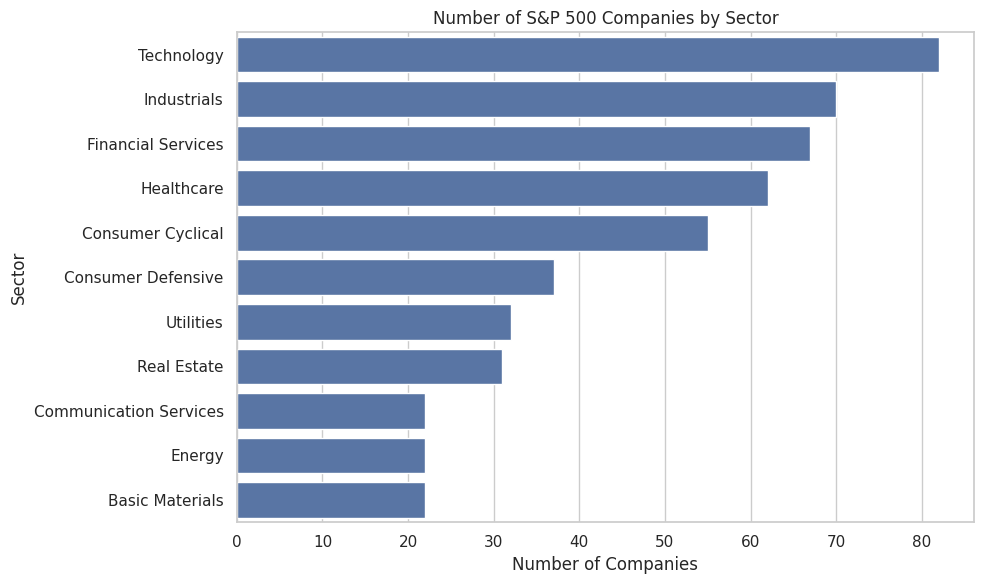

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=sector_counts.values,
    y=sector_counts.index
)

plt.title("Number of S&P 500 Companies by Sector")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

### Which Sectors Actually Contain the Most Money?

In [15]:
sector_marketcap = (
    df.groupby("sector")["marketcap_b"]
      .sum()
      .sort_values(ascending=False)
)

sector_marketcap

sector
Technology               17,287.01
Communication Services    7,804.05
Financial Services        7,108.16
Consumer Cyclical         6,372.35
Healthcare                5,190.43
Industrials               3,764.60
Consumer Defensive        3,253.84
Energy                    1,598.67
Utilities                 1,257.37
Real Estate               1,081.49
Basic Materials             864.55
Name: marketcap_b, dtype: float64

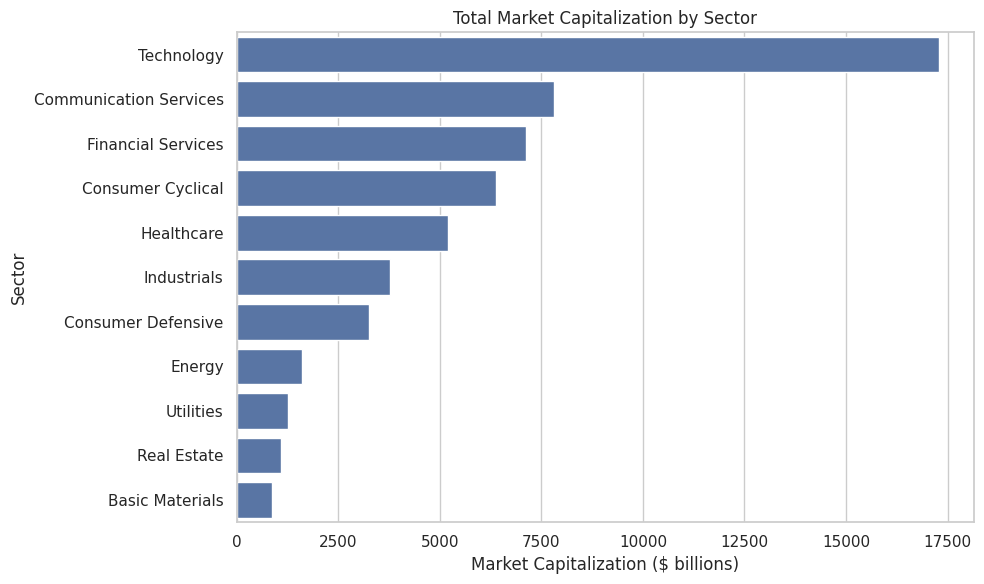

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=sector_marketcap.values,
    y=sector_marketcap.index
)

plt.title("Total Market Capitalization by Sector")
plt.xlabel("Market Capitalization ($ billions)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

### Top 10 Companies

In [17]:
top10 = (
    df.nlargest(10, "marketcap")
)

top10[
    [
        "symbol",
        "shortname",
        "sector",
        "marketcap_b",
        "weight_pct"
    ]
]

,symbol,shortname,sector,marketcap_b,weight_pct
0,AAPL,Apple Inc.,Technology,"3,846.82",6.92
1,NVDA,NVIDIA Corporation,Technology,"3,298.80",5.93
2,MSFT,Microsoft Corporation,Technology,"3,246.07",5.84
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,"2,365.03",4.25
4,GOOGL,Alphabet Inc.,Communication Services,"2,351.63",4.23
5,GOOG,Alphabet Inc.,Communication Services,"2,351.62",4.23
6,META,"Meta Platforms, Inc.",Communication Services,"1,477.46",2.66
7,TSLA,"Tesla, Inc.",Consumer Cyclical,"1,351.63",2.43
8,AVGO,Broadcom Inc.,Technology,"1,031.22",1.86
9,BRK-B,Berkshire Hathaway Inc. New,Financial Services,978.78,1.76


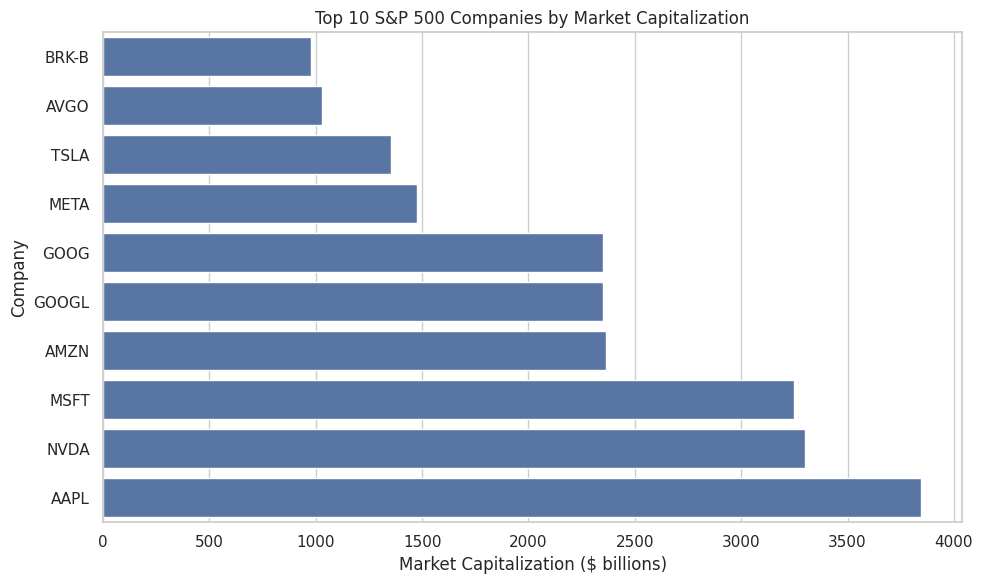

In [18]:
plt.figure(figsize=(10, 6))

plot_data = top10.sort_values("marketcap_b")

sns.barplot(
    data=plot_data,
    x="marketcap_b",
    y="symbol"
)

plt.title("Top 10 S&P 500 Companies by Market Capitalization")
plt.xlabel("Market Capitalization ($ billions)")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

### S&P 500 concentration

In [19]:
total_marketcap = df["marketcap"].sum()

for n in [5, 10, 20, 50, 100]:
    top_n_marketcap = df.nlargest(n, "marketcap")["marketcap"].sum()
    
    share = top_n_marketcap / total_marketcap * 100
    
    print(f"Top {n}: {share:.2f}%")

Top 5: 27.18%
Top 10: 40.12%
Top 20: 49.87%
Top 50: 62.89%
Top 100: 74.98%


## Revenue Growth

In [20]:
df["revenue_growth_pct"].describe()

count   499.00
mean      7.05
std      18.02
min     -60.20
25%       0.20
50%       5.10
75%      10.90
max     163.20
Name: revenue_growth_pct, dtype: float64

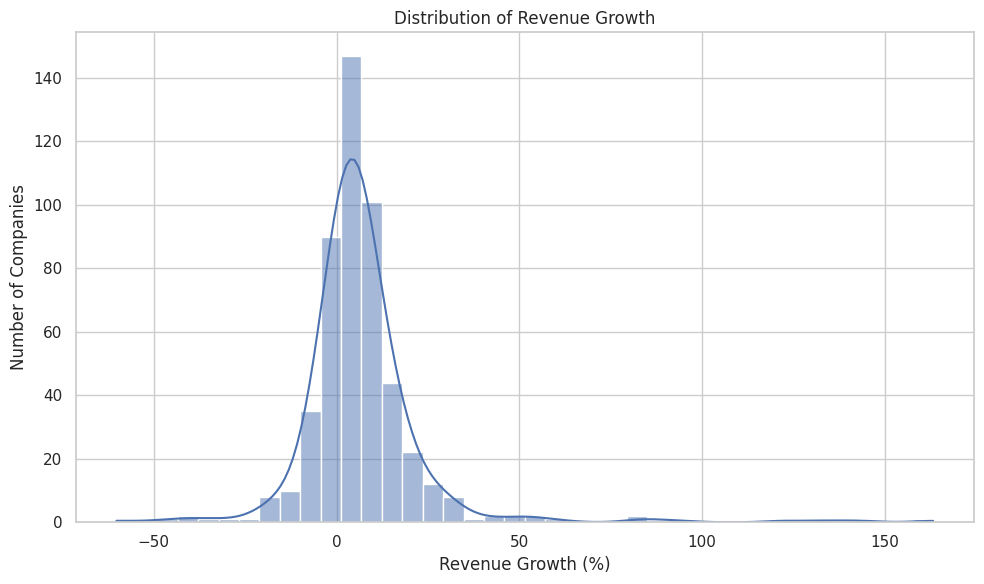

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["revenue_growth_pct"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Revenue Growth")
plt.xlabel("Revenue Growth (%)")
plt.ylabel("Number of Companies")

plt.tight_layout()
plt.show()

### Compare Sectors

In [22]:
sector_growth = (
    df.groupby("sector")["revenue_growth_pct"]
      .median()
      .sort_values(ascending=False)
)

sector_growth

sector
Financial Services       11.60
Real Estate               7.20
Technology                7.10
Healthcare                6.00
Utilities                 4.20
Communication Services    4.10
Consumer Cyclical         4.10
Industrials               3.10
Basic Materials           0.30
Consumer Defensive       -0.30
Energy                   -1.35
Name: revenue_growth_pct, dtype: float64

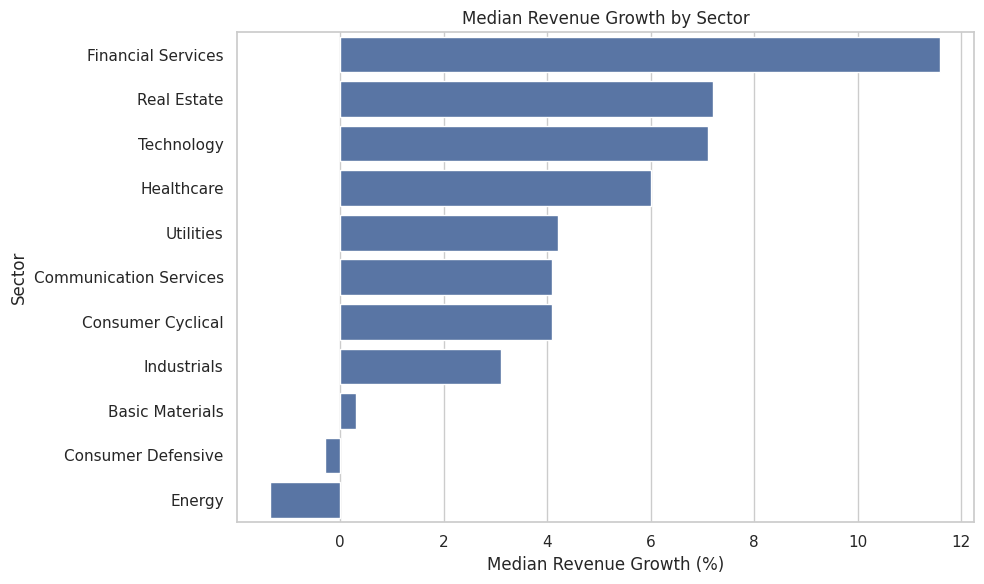

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=sector_growth.values,
    y=sector_growth.index
)

plt.title("Median Revenue Growth by Sector")
plt.xlabel("Median Revenue Growth (%)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

### Market cap vs revenue growth

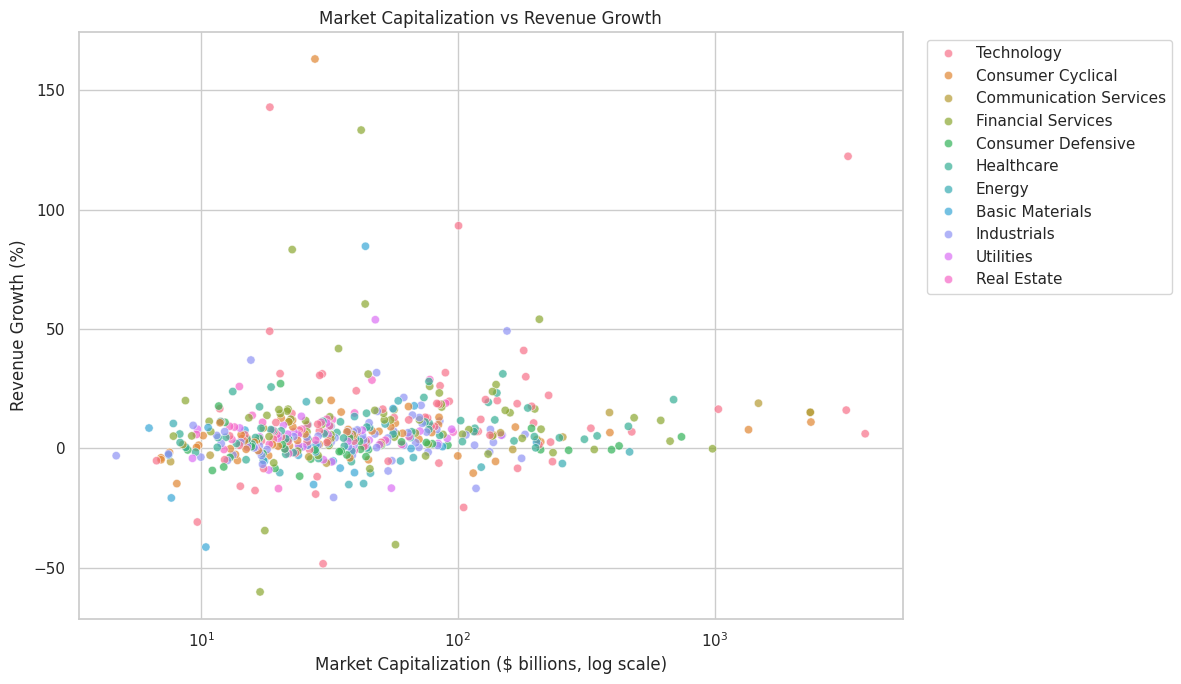

In [24]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="marketcap_b",
    y="revenue_growth_pct",
    hue="sector",
    alpha=0.7
)

plt.xscale("log")

plt.title("Market Capitalization vs Revenue Growth")
plt.xlabel("Market Capitalization ($ billions, log scale)")
plt.ylabel("Revenue Growth (%)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Correlation Analysis

In [25]:
correlation_columns = [
    "currentprice",
    "marketcap_b",
    "ebitda_b",
    "revenue_growth_pct",
    "employees_k",
    "weight_pct"
]

corr = df[correlation_columns].corr()

corr

,currentprice,marketcap_b,ebitda_b,revenue_growth_pct,employees_k,weight_pct
currentprice,1.00,0.05,0.02,0.04,-0.01,0.05
marketcap_b,0.05,1.00,0.85,0.16,0.34,1.00
ebitda_b,0.02,0.85,1.00,0.07,0.40,0.85
revenue_growth_pct,0.04,0.16,0.07,1.00,-0.01,0.16
employees_k,-0.01,0.34,0.40,-0.01,1.00,0.34
weight_pct,0.05,1.00,0.85,0.16,0.34,1.00


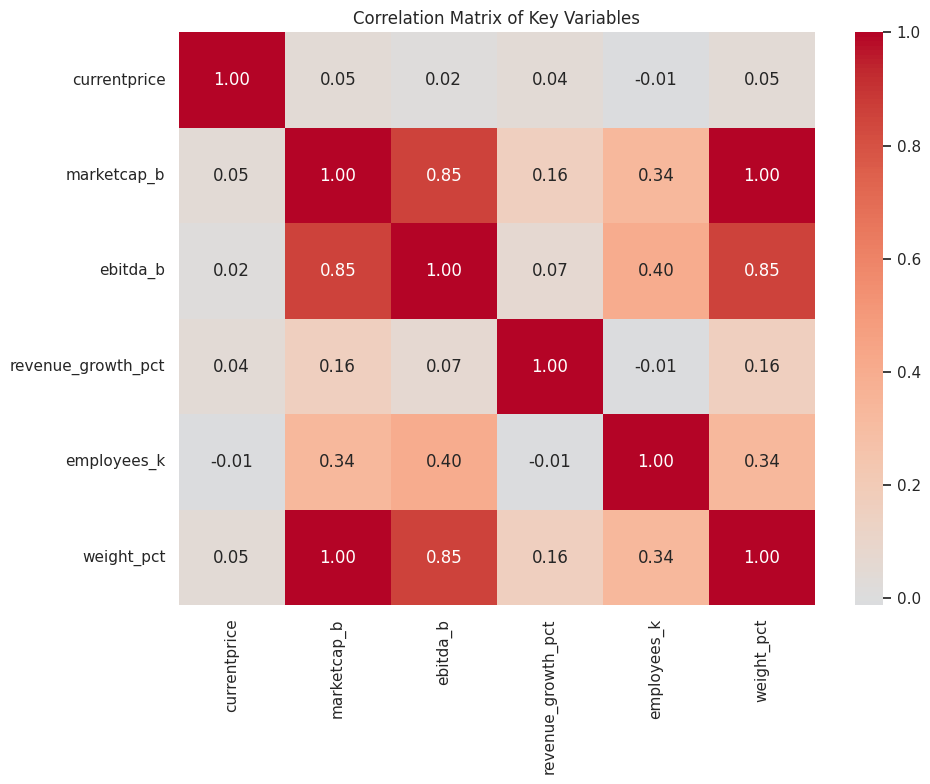

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Key Variables")

plt.tight_layout()
plt.show()

### Employee Analysis

In [27]:
top_employers = (
    df.nlargest(10, "fulltimeemployees")
)

top_employers[
    [
        "symbol",
        "shortname",
        "sector",
        "fulltimeemployees"
    ]
]

,symbol,shortname,sector,fulltimeemployees
10,WMT,Walmart Inc.,Consumer Defensive,"2,100,000.00"
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,"1,551,000.00"
32,ACN,Accenture plc,Technology,"774,000.00"
91,UPS,"United Parcel Service, Inc.",Industrials,"500,000.00"
20,HD,"Home Depot, Inc. (The)",Consumer Cyclical,"465,000.00"
17,UNH,UnitedHealth Group Incorporated,Healthcare,"440,000.00"
163,TGT,Target Corporation,Consumer Defensive,"415,000.00"
207,KR,Kroger Company (The),Consumer Defensive,"414,000.00"
124,MAR,Marriott International,Consumer Cyclical,"411,000.00"
9,BRK-B,Berkshire Hathaway Inc. New,Financial Services,"396,500.00"


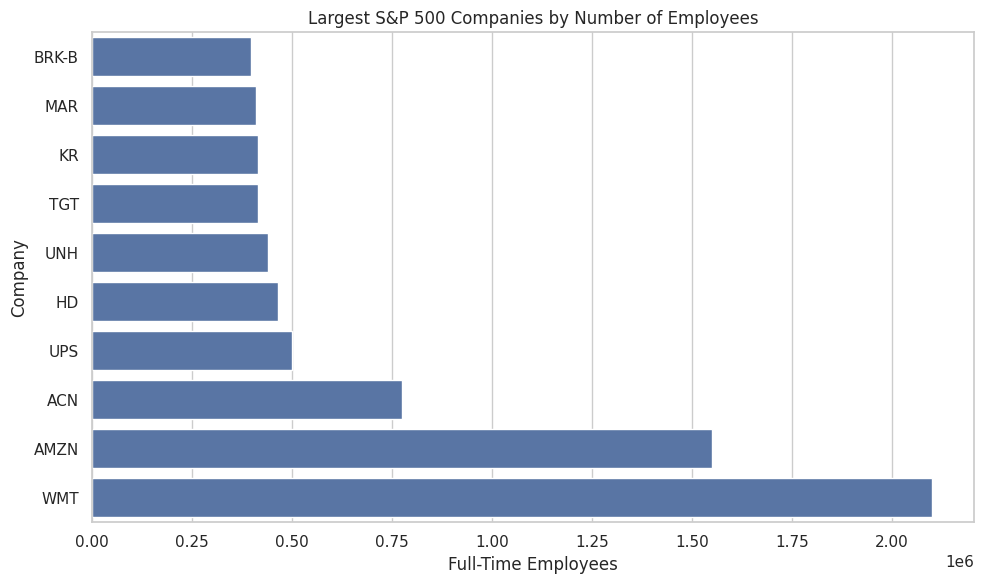

In [28]:
plt.figure(figsize=(10, 6))

plot_data = top_employers.sort_values("fulltimeemployees")

sns.barplot(
    data=plot_data,
    x="fulltimeemployees",
    y="symbol"
)

plt.title("Largest S&P 500 Companies by Number of Employees")
plt.xlabel("Full-Time Employees")
plt.ylabel("Company")

plt.tight_layout()
plt.show()

### EBITDA

In [29]:
sector_ebitda = (
    df.groupby("sector")["ebitda_b"]
      .sum()
      .sort_values(ascending=False)
)

sector_ebitda

sector
Technology               627.43
Communication Services   561.13
Healthcare               382.03
Consumer Cyclical        342.95
Financial Services       337.04
Industrials              273.15
Energy                   257.47
Consumer Defensive       236.76
Utilities                162.80
Basic Materials           80.16
Real Estate               71.49
Name: ebitda_b, dtype: float64

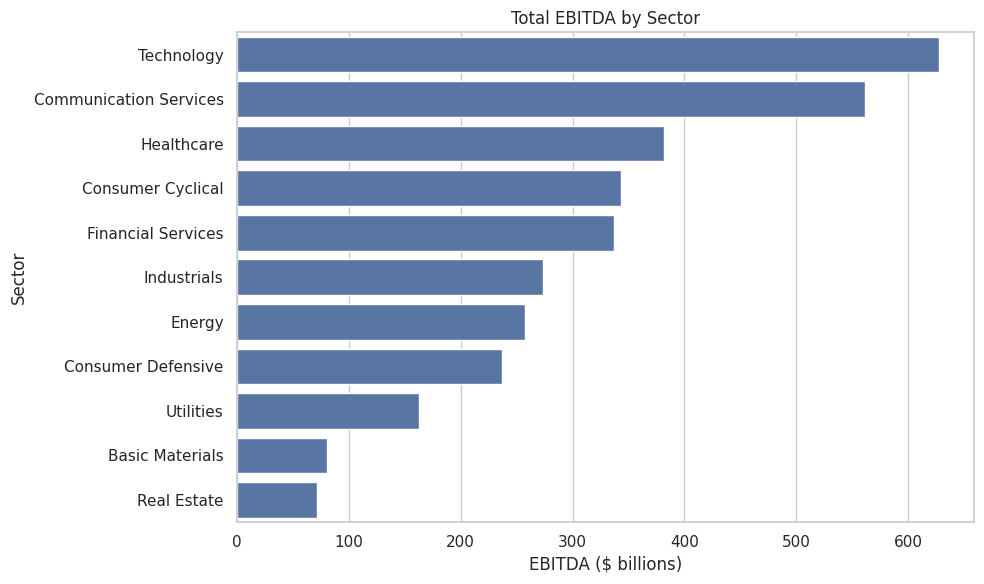

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=sector_ebitda.values,
    y=sector_ebitda.index
)

plt.title("Total EBITDA by Sector")
plt.xlabel("EBITDA ($ billions)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

### Geographic Analysis

In [31]:
state_counts = (
    df[df["country"] == "United States"]["state"]
    .value_counts()
    .head(15)
)

state_counts

state
CA    67
NY    49
TX    48
IL    32
OH    22
MA    22
PA    20
VA    17
GA    17
FL    17
MN    15
NJ    15
CT    14
NC    13
WA    12
Name: count, dtype: int64

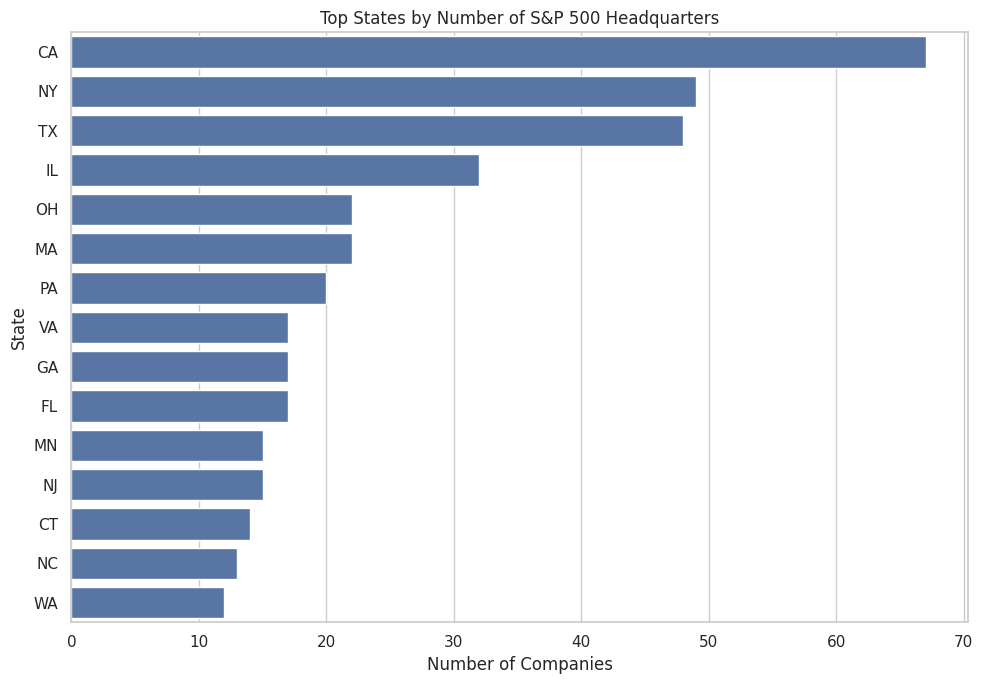

In [32]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=state_counts.values,
    y=state_counts.index
)

plt.title("Top States by Number of S&P 500 Headquarters")
plt.xlabel("Number of Companies")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## Final Insights

## Key Findings and Business Insights

### 1. Technology has a dominant position in the S&P 500

Technology is the largest sector in the dataset both in terms of the number of constituent companies and, more importantly, total market capitalization. This indicates that the influence of the Technology sector extends beyond simply having a large number of companies. Its companies collectively represent a substantial proportion of the overall market value.

This concentration suggests that movements in large technology companies can have a significant impact on the broader S&P 500.

### 2. Market capitalization is highly concentrated

The market capitalization analysis shows a substantial difference between the largest companies and the rest of the index. Companies such as Apple, Nvidia, and Microsoft have market capitalizations measured in trillions of dollars, while many other constituents are considerably smaller.

Therefore, the S&P 500 should not be viewed as an equally weighted collection of 500 companies. The largest constituents have a disproportionately large influence on the aggregate market capitalization and index exposure.

### 3. Company count and economic influence are not the same

The comparison between the number of companies and total market capitalization demonstrates that sectors with many constituents do not necessarily represent the largest share of market value.

For example, Industrials has a large number of companies, but its aggregate market capitalization is substantially lower than Technology. This highlights the importance of considering both **sector composition** and **economic weight** when analyzing an index.

### 4. Revenue growth varies substantially across sectors

Revenue growth is not evenly distributed across the S&P 500. The distribution is concentrated around relatively moderate growth rates but contains several extreme observations, resulting in a right-skewed distribution.

The sector-level analysis shows meaningful differences in median revenue growth. Financial Services and Real Estate display relatively strong median growth in this dataset, while Energy and Consumer Defensive show weaker or negative median growth.

Because extreme observations can strongly affect the mean, the median provides a more robust measure for comparing typical sector growth.

### 5. High growth does not necessarily mean large market capitalization

The relationship between market capitalization and revenue growth does not indicate that the largest companies are automatically the fastest-growing companies. Large established companies can have relatively moderate growth, while smaller companies can experience much higher growth rates.

This illustrates an important business principle: **company size and growth are different dimensions of performance**.

### 6. Technology leads in aggregate EBITDA

Technology also records the highest total EBITDA among the sectors in the dataset. Communication Services and Healthcare follow, while Real Estate and Basic Materials have substantially lower aggregate EBITDA.

The combination of high market capitalization and high EBITDA reinforces the importance of Technology within this particular S&P 500 snapshot.

However, total EBITDA is influenced by the number and size of companies in each sector, so it should not be interpreted as a direct measure of sector profitability.

### 7. Headquarters are geographically concentrated

S&P 500 headquarters are heavily concentrated in a relatively small number of U.S. states. California has the highest number of companies in the dataset, followed by New York and Texas.

This concentration reflects the importance of major economic and business centers in the United States. However, headquarters location should not be interpreted as the geographic distribution of a company's operations or revenues.

### 8. Overall business implication

The analysis suggests that the S&P 500 is characterized by **strong differences in company size, sector influence, growth, and operating scale**. A relatively small group of very large companies—particularly within Technology—has a substantial influence on the overall market.

At the same time, revenue growth varies considerably across sectors and does not simply increase with company size. Therefore, evaluating S&P 500 companies requires considering multiple dimensions simultaneously, including **market capitalization, growth, EBITDA, workforce size, and sector classification**.

### Limitations

This analysis is based on a cross-sectional snapshot of S&P 500 companies rather than a historical time series. Therefore, the results describe the characteristics of the companies represented in the dataset but cannot establish how these relationships change over time.

In addition, correlation and descriptive comparisons should not be interpreted as evidence of causation.

### Conclusion

Overall, the exploratory analysis demonstrates that the S&P 500 is highly diverse but also significantly concentrated in terms of market value. Technology stands out as the dominant sector, while a relatively small number of large companies account for a substantial portion of total market capitalization. Revenue growth shows considerable variation across sectors and companies, demonstrating that scale and growth are not necessarily equivalent.

These findings provide a strong foundation for further financial analysis, such as combining the dataset with historical stock prices to investigate sector performance, volatility, valuation, and the relationship between company fundamentals and subsequent market returns.